In [960]:
import numpy as np 
import pandas as pd 


In [961]:
df =  pd.read_csv('./data/startup_funding.csv')
df.head()


,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [962]:
df.shape

(3044, 10)

In [963]:
# uniqe company names who are funded
df['Startup Name'].unique()



array(['BYJU’S', 'Shuttl', 'Mamaearth', ..., 'Graphene', 'Simplotel',
       'couponmachine.in'], dtype=object)

In [964]:
# no of uniqe company names who are funded
df['Startup Name'].nunique()

2459

In [965]:
# uniqe investors names 

In [966]:
df['Investors Name'].isna().sum() ## number of null values in investors name column

24

In [967]:
# fill up the null values in investors name column with 'Not Disclosed'
df["Investors Name"] = df["Investors Name"].fillna("Not Disclosed")
df['Investors Name'].isna().sum() ## number of null values in investors name column

0

In [968]:
df["Investors Name"].unique().tolist()

['Tiger Global Management',
 'Susquehanna Growth Equity',
 'Sequoia Capital India',
 'Vinod Khatumal',
 'Sprout Venture Partners',
 'Chiratae Ventures',
 'Ant Financial',
 'Sathguru Catalyzer Advisors',
 'Ping An Global Voyager Fund',
 'Mumbai Angels, Ravikanth Reddy',
 'SAIF Partners, Spring Canter Investment Ltd.',
 'Paytm, NPTK, Sabre Partners and Neoplux',
 'Vertex Growth Fund',
 'Not Disclosed',
 'Ruizheng Investment',
 'Manipal Education and Medical Group (MEMG)',
 'SoftBank Vision Fund',
 'Sequoia, CapitalG, Accel',
 'Sauce.vc, Rainforest Ventures',
 'Prime Venture Partners, LetsVenture, PS1 Venture and GlobalLogic co-founder Rajul Garg',
 'RB Investments',
 'DG Daiwa Ventures, DG Incubation',
 'Trifecta Capital Advisors',
 'FinTech',
 'Dream Incubator',
 'Altimeter Capital, Sutter Hill Ventures',
 'Startup Buddy',
 'Amour Infrastructure',
 'Ackermans & van Haaren, HealthQuad, Rebright Partners, Toppan Printing',
 'Matrix Partners, Stellaris Venture Partners, Kalaari Capital',
 

In [969]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3044 entries, 0 to 3043
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Sr No              3044 non-null   int64 
 1   Date dd/mm/yyyy    3044 non-null   object
 2   Startup Name       3044 non-null   object
 3   Industry Vertical  2873 non-null   object
 4   SubVertical        2108 non-null   object
 5   City  Location     2864 non-null   object
 6   Investors Name     3044 non-null   object
 7   InvestmentnType    3040 non-null   object
 8   Amount in USD      2084 non-null   object
 9   Remarks            419 non-null    object
dtypes: int64(1), object(9)
memory usage: 237.9+ KB


In [970]:
df.drop(columns=["Remarks"] , inplace=True)
df.head()

,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860"
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000"
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000"


In [971]:
df.set_index("Sr No" , inplace=True)

In [972]:
df.rename(columns={
    'Date dd/mm/yyyy' : 'Date',
    'Startup Name' : 'startup',
    'Industry Vertical' : 'Industry',
    'SubVertical' : 'SubIndustry',
    'City  Location' : 'City',
    'Investors Name' : 'Investors',
    'InvestmentnType' : 'round',
    'Amount in USD' : 'Amount'
} , inplace=True )


In [973]:
df.head(2)

,Date,startup,Industry,SubIndustry,City,Investors,round,Amount
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000"
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394"


In [974]:
#conver amount to CR

df.info()  # Amount   2084 non-null   object

<class 'pandas.core.frame.DataFrame'>
Index: 3044 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         3044 non-null   object
 1   startup      3044 non-null   object
 2   Industry     2873 non-null   object
 3   SubIndustry  2108 non-null   object
 4   City         2864 non-null   object
 5   Investors    3044 non-null   object
 6   round        3040 non-null   object
 7   Amount       2084 non-null   object
dtypes: object(8)
memory usage: 214.0+ KB


In [975]:
## and some null values in amount colmn . lets fill that up with amount - 0  that represents undisclosed amount
df['Amount'] = df['Amount'].fillna('0')

In [976]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3044 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         3044 non-null   object
 1   startup      3044 non-null   object
 2   Industry     2873 non-null   object
 3   SubIndustry  2108 non-null   object
 4   City         2864 non-null   object
 5   Investors    3044 non-null   object
 6   round        3040 non-null   object
 7   Amount       3044 non-null   object
dtypes: object(8)
memory usage: 214.0+ KB


In [977]:
df["Amount"].value_counts().sort_values()

Amount
\\xc2\\xa016,200,000      1
4,37,000                  1
2,90,00,000               1
4,97,00,000               1
2,80,000                  1
                       ... 
30,00,000                66
20,00,000                69
5,00,000                108
10,00,000               165
0                       960
Name: count, Length: 472, dtype: int64

In [978]:
df["Amount"]  = df["Amount"].str.replace(',' , '')  # remove commas from amount column
df["Amount"] = df["Amount"].str.replace('undisclosed','0')
df["Amount"] = df["Amount"].str.replace('unknown','0')
df["Amount"] = df["Amount"].str.replace('N/A','0')
df["Amount"] = df["Amount"].str.replace('Undisclosed','0')
df["Amount"] = df["Amount"].str.strip("+")
df["Amount"]

Sr No
1       200000000
2         8048394
3        18358860
4         3000000
5         1800000
          ...    
3040      4500000
3041       825000
3042      1500000
3043            0
3044       140000
Name: Amount, Length: 3044, dtype: object

In [979]:
# df["Amount"].astype('float64')

In [980]:
df["Amount"].str.isdigit().value_counts()

Amount
True     3030
False      14
Name: count, dtype: int64

In [981]:
df = df[df["Amount"].str.isdigit()]  ## removing the 14 rows which are not digits in amount column 
df.shape

(3030, 8)

In [982]:
df["Amount"] = df["Amount"].astype('float')

In [983]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3030 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         3030 non-null   object 
 1   startup      3030 non-null   object 
 2   Industry     2859 non-null   object 
 3   SubIndustry  2105 non-null   object 
 4   City         2850 non-null   object 
 5   Investors    3030 non-null   object 
 6   round        3028 non-null   object 
 7   Amount       3030 non-null   float64
dtypes: float64(1), object(7)
memory usage: 213.0+ KB


In [984]:
def to_inr(dollar): 
    inr = dollar * 82.5
    return inr

In [985]:
df["Amount"] = df["Amount"].apply(to_inr)

In [986]:

df

,Date,startup,Industry,SubIndustry,City,Investors,round,Amount
Sr No,,,,,,,,
1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1.650000e+10
2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,6.639925e+08
3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,1.514606e+09
4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,2.475000e+08
5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,1.485000e+08
...,...,...,...,...,...,...,...,...
3040,29/01/2015,Printvenue,NaN,NaN,NaN,Asia Pacific Internet Group,Private Equity,3.712500e+08
3041,29/01/2015,Graphene,NaN,NaN,NaN,KARSEMVEN Fund,Private Equity,6.806250e+07
3042,30/01/2015,Mad Street Den,NaN,NaN,NaN,"Exfinity Fund, GrowX Ventures.",Private Equity,1.237500e+08


In [987]:
# Date Columns 

df["Date"] = pd.to_datetime(df["Date"] , format='%d/%m/%Y' , errors='coerce')  ## errors = 'coerce' will convert the invalid date to NaT

In [988]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3030 entries, 1 to 3044
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         3023 non-null   datetime64[ns]
 1   startup      3030 non-null   object        
 2   Industry     2859 non-null   object        
 3   SubIndustry  2105 non-null   object        
 4   City         2850 non-null   object        
 5   Investors    3030 non-null   object        
 6   round        3028 non-null   object        
 7   Amount       3030 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 213.0+ KB


In [989]:
df.dropna(subset=["Date" , "startup" , "Industry" , "City" , "Investors" , "round" , "Amount"] , inplace=True)  ## drop the rows which have invalid date values

In [990]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2843 entries, 1 to 2873
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         2843 non-null   datetime64[ns]
 1   startup      2843 non-null   object        
 2   Industry     2843 non-null   object        
 3   SubIndustry  2096 non-null   object        
 4   City         2843 non-null   object        
 5   Investors    2843 non-null   object        
 6   round        2843 non-null   object        
 7   Amount       2843 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(6)
memory usage: 199.9+ KB


In [991]:
# normalized cr values 
df["Amount"] = df["Amount"].apply(lambda x : x/10000000)  ## convert the amount to CR

In [992]:
df.to_csv("./data/startup_funding_cleaned.csv")

In [993]:
df_cleaned = pd.read_csv("./data/startup_funding_cleaned.csv")

In [994]:
df.shape

(2843, 8)

In [995]:
((3044-2843)/3044)*100  # 6 percent data loss  no problem 

6.603153745072274

In [996]:
df_cleaned["Investors"].str.split(",").sum()

['Tiger Global Management',
 'Susquehanna Growth Equity',
 'Sequoia Capital India',
 'Vinod Khatumal',
 'Sprout Venture Partners',
 'Chiratae Ventures',
 'Ant Financial',
 'Sathguru Catalyzer Advisors',
 'Ping An Global Voyager Fund',
 'Mumbai Angels',
 ' Ravikanth Reddy',
 'SAIF Partners',
 ' Spring Canter Investment Ltd.',
 'Paytm',
 ' NPTK',
 ' Sabre Partners and Neoplux',
 'Vertex Growth Fund',
 'Not Disclosed',
 'Ruizheng Investment',
 'Manipal Education and Medical Group (MEMG)',
 'SoftBank Vision Fund',
 'Sequoia',
 ' CapitalG',
 ' Accel',
 'Sauce.vc',
 ' Rainforest Ventures',
 'Prime Venture Partners',
 ' LetsVenture',
 ' PS1 Venture and GlobalLogic co-founder Rajul Garg',
 'RB Investments',
 'DG Daiwa Ventures',
 ' DG Incubation',
 'Trifecta Capital Advisors',
 'FinTech',
 'Dream Incubator',
 'Altimeter Capital',
 ' Sutter Hill Ventures',
 'Startup Buddy',
 'Amour Infrastructure',
 'Ackermans & van Haaren',
 ' HealthQuad',
 ' Rebright Partners',
 ' Toppan Printing',
 'Matrix P

In [997]:
len(df_cleaned["Investors"].str.split(",").sum())

5445

In [998]:
len(set(df_cleaned["Investors"].str.split(",").sum()))

3458

In [999]:
len(list(set(set(df_cleaned["Investors"].str.split(",").sum()))))

3458

2. Investor POV
   * Name
   * Recent Investments
   * Biggest investments
   * Generally invests in ...
   * sector ->pie
   * stage ->pie
   * city -> pie
   * YoY investment graph
   * Similar Investors

In [1000]:
## find out the investors data 
df[df['Investors'].str.contains("IDG", na=False)].sort_values(by="Date" , ascending=False).head(5)[["Date" , "startup" , "Industry" , "City" , "Investors" , "round" , "Amount"]]

,Date,startup,Industry,City,Investors,round,Amount
Sr No,,,,,,,
102,2019-04-13,Tripoto,Social Media,New Delhi,"Orchid India, Hornbill Orchid India Fund, Chir...",Series B,29.628844
223,2018-07-30,Cure Fit,Consumer Internet,Bengaluru,"IDG Ventures, Accel Partners, Kalaari Capital ...",Private Equity,990.000000
253,2018-06-26,Sigtuple,Healthcare,Bengaluru,"Accel Partners, IDG Venture, Endiya Partners, ...",Private Equity,156.750000
259,2018-05-02,Bizongo,Consumer Internet,Mumbai,"B Capital, International Finance Corporation (...",Private Equity,181.500000
310,2018-04-26,POPxo,Technology,Delhi,"Neoplux, OPPO, IDG Ventures India, Kalaari Cap...",Private Equity,45.375000


In [1001]:
## a inverstor in which companies we invested and how much amount we invested in each company and how many rounds we invested in each company

df[df['Investors'].str.contains("IDG")].groupby("startup")["Amount"].sum().sort_values(ascending=False)

startup
Cure Fit                 990.000000
Lenskart                 495.000000
Bizongo                  206.250000
CureFit                  206.250000
Sigtuple                 204.600000
Curefit                  123.750000
Fintellix                123.750000
Xpressbees               103.125000
FirstCry.com              82.500000
Uniphore                  72.600000
POPxo                     70.950000
HealthifyMe               49.500000
\\xc2\\xa0CloudCherry     49.500000
Flyrobe                   43.725000
Aasaanjobs                41.250000
RentMojo                  41.250000
Vayana                    33.000000
PlaySimple                33.000000
Agrostar                  33.000000
Blowhorn                  30.112500
Tripoto                   29.628844
Active.ai                 24.750000
Heckyl                    22.275000
CreditMantri              20.625000
eShakti                   18.975000
RentoMojo                 16.500000
POPxo.com                 16.500000
Zimmber             

In [1002]:
##  * Generally invests in ...  group by {industry}

<Axes: ylabel='Amount'>

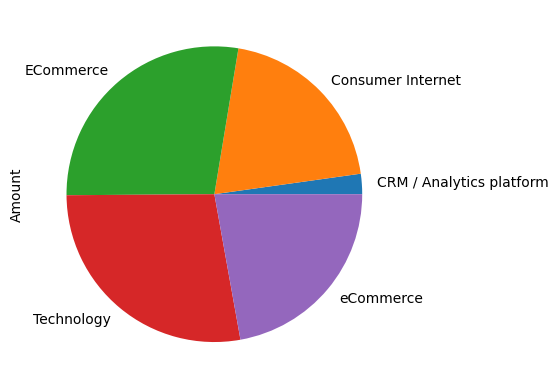

In [1003]:
df[df['Investors'].str.contains(" IDG Ventures ")].groupby("Industry")["Amount"].sum().plot(kind="pie")

In [1004]:
##  * Generally invests in which round ...  group by {round}

In [1005]:
df[df['Investors'].str.contains(" IDG Ventures ")].groupby("round")["Amount"].sum()

round
Private Equity    363.825
Seed Funding        8.250
Name: Amount, dtype: float64

<Axes: ylabel='Amount'>

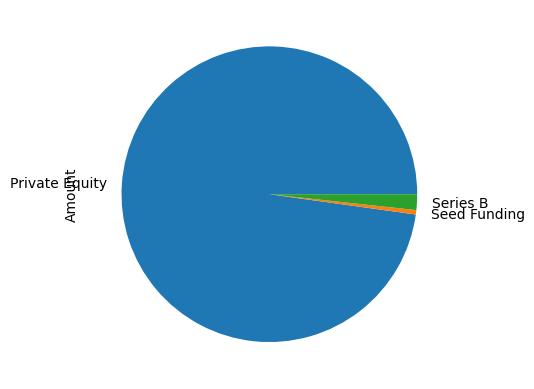

In [1006]:
df[df['Investors'].str.contains(" IDG ")].groupby("round")["Amount"].sum().plot(kind="pie")

In [1007]:
## YOY (year on year) investement total investment amount by year
df["Year"] = df["Date"].dt.year
df.head()

,Date,startup,Industry,SubIndustry,City,Investors,round,Amount,Year
Sr No,,,,,,,,,
1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000,2020
2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250,2020
3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595,2020
4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000,2020
5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000,2020


<Axes: xlabel='Year'>

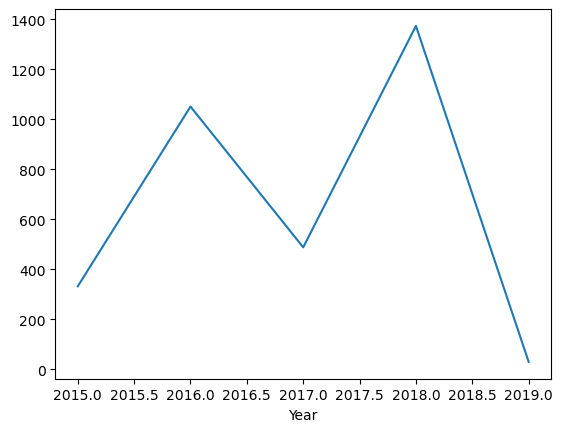

In [1008]:
df[df["Investors"].str.contains("IDG")].groupby("Year")["Amount"].sum().plot()

In [1009]:
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"] , format='%Y-%m-%d' , errors='coerce')  ## errors = 'coerce' will convert the invalid date to NaT

In [1010]:
df_cleaned["Date"].min()

Timestamp('2015-04-03 00:00:00')

In [1011]:
df_cleaned["Month"] = df_cleaned["Date"].dt.month
df_cleaned["Year"] = df_cleaned["Date"].dt.year
df_cleaned

,Sr No,Date,startup,Industry,SubIndustry,City,Investors,round,Amount,Month,Year
0,1,2020-01-09,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,1650.000000,1,2020
1,2,2020-01-13,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,66.399250,1,2020
2,3,2020-01-09,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,151.460595,1,2020
3,4,2020-01-02,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,24.750000,1,2020
4,5,2020-01-02,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,14.850000,1,2020
...,...,...,...,...,...,...,...,...,...,...,...
2838,2869,2015-04-29,Tracxn,Startup Analytics platform,NaN,Bangalore,SAIF Partners,Private Equity,28.875000,4,2015
2839,2870,2015-04-29,Dazo,Mobile Food Ordering app,NaN,Bangalore,"Sumit Jain, Aprameya Radhakrishna, Alok Goel, ...",Seed Funding,0.000000,4,2015
2840,2871,2015-04-29,Tradelab,Financial Markets Software,NaN,Bangalore,Rainmatter,Seed Funding,3.300000,4,2015
2841,2872,2015-04-29,PiQube,Hiring Analytics platform,NaN,Chennai,The HR Fund,Seed Funding,4.125000,4,2015


In [1012]:
gp_y_m = df_cleaned.groupby(["Year" , "Month"])

In [1029]:
## total amount invested by year and month
import plotly.express as px

monthly = (
    df_cleaned.groupby(["Year", "Month"])["Amount"]
    .sum().reset_index()
    .sort_values(["Year", "Month"])
)

monthly

monthly["YearMonth"] = pd.to_datetime(
    monthly["Year"].astype(str) + "-" +
    monthly["Month"].astype(str) + "-01"
)

fig = px.line(
    monthly,
    x="YearMonth",
    y="Amount",
    markers=True,
    title="Monthly Investment Amount"
)

fig.update_layout(
    xaxis_title="Year-Month",
    yaxis_title="Amount",
    hovermode="x unified"
)

fig.show()




In [1040]:
## total number of startups funded by year and month
monthly =  gp_y_m["startup"].count().reset_index()
monthly["YearMonth"] = pd.to_datetime(
    monthly["Year"].astype(str) + "-" +
    monthly["Month"].astype(str) + "-01"
)
monthly
import plotly.express as px

fig = px.line(
    monthly,
    x="YearMonth",
    y="startup",
    markers=True,
    title="Monthly Investment Counts"
)

fig.update_layout(
    xaxis_title="Year-Month",
    yaxis_title="Count of Startups Funded",
    hovermode="x unified"
)

fig.show()
